# XGBoost — Anti-Money Laundering (AML)
## Comparación de métodos de búsqueda de hiperparámetros

**Proyecto:** Detección de lavado de dinero con XGBoost  
**Métodos evaluados:** Grid Search · Random Search · Bayesiano (Optuna/TPE) · Genético (DEAP)  
**Configuraciones XGBoost:** `hist` (estándar) y `hist+ES` (con early stopping)


# XGBoost para Detección de Lavado de Dinero

## ¿Qué es XGBoost?

XGBoost (eXtreme Gradient Boosting) es un algoritmo de aprendizaje automático basado en 
árboles de decisión que utiliza boosting para mejorar iterativamente sus predicciones.

### Características principales:
- **Algoritmo de Boosting**: Combina múltiples árboles débiles en un modelo fuerte
- **Regularización**: Penaliza modelos complejos para evitar sobreajuste
- **Manejo de datos desbalanceados**: Perfecto para datasets donde el fraude es raro
- **Feature importance**: Identifica qué variables son más importantes para la predicción

## ¿Por qué XGBoost para AML?

En detección de lavado de dinero, necesitamos un modelo que:
1. Capture relaciones **no lineales** entre variables (XGBoost lo hace muy bien)
2. Minimice **falsos negativos** (no queremos dejar pasar fraude)
3. Sea **interpretable** (reguladores requieren entender las decisiones)

XGBoost es de los modelos más usados en competencias Kaggle y problemas financieros reales.

## Sección 1 · Imports y Configuración

In [ ]:
# Instalar dependencias (descomentar si es necesario)
!pip install deap optuna -q

import warnings, time, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import loguniform, randint, uniform

from sklearn.base            import BaseEstimator, ClassifierMixin
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc,
    f1_score, roc_auc_score, accuracy_score
)

from imblearn.pipeline      import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.base          import BaseSampler
from xgboost                import XGBClassifier

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from deap import base, creator, tools, algorithms

warnings.filterwarnings("ignore")
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 60.1 MB/s eta 0:00:00


In [ ]:
# ── Constantes globales ────────────────────────────────────────────────────────
RANDOM_STATE    = 42
N_SPLITS        = 3     # TimeSeriesSplit folds (cronológico, nunca KFold aleatorio)
N_ITER_RANDOM   = 20    # Random Search: iteraciones por estrategia de balanceo
N_TRIALS_OPTUNA = 30    # Optuna: trials totales (incluye balance como hiperparámetro)
POP_SIZE        = 10    # DEAP: tamaño de la población
N_GEN           = 5     # DEAP: número de generaciones
BASE_PATH       = '/content/drive/MyDrive/Datasets/Final Project/Processed/'

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Sección 2 · Clases Auxiliares

- **`IdentitySampler`** — bypass que no aplica oversampling.  
- **`DynamicBalanceXGB`** — XGBoost con `tree_method='hist'`; calcula `scale_pos_weight` dentro de cada fold para evitar *data leakage*.  
- **`DynamicBalanceXGB_ES`** — igual que el anterior pero con *early stopping* (requiere `eval_set`).


In [ ]:
class IdentitySampler(BaseSampler):
    """Bypass: no aplica ningún oversampling, pasa los datos tal cual."""
    _sampling_type         = "bypass"
    _parameter_constraints = {}

    def _fit_resample(self, X, y):
        return X, y

    def __repr__(self):
        return "IdentitySampler()"


class DynamicBalanceXGB(BaseEstimator, ClassifierMixin):
    """
    Wrapper de XGBoost con tree_method='hist'.
    Calcula scale_pos_weight DENTRO del fold activo para evitar data leakage.
    """
    def __init__(self, use_balanced_weight=False, learning_rate=0.1,
                 max_depth=6, n_estimators=100, subsample=1.0,
                 colsample_bytree=1.0, random_state=RANDOM_STATE):
        self.use_balanced_weight = use_balanced_weight
        self.learning_rate       = learning_rate
        self.max_depth           = max_depth
        self.n_estimators        = n_estimators
        self.subsample           = subsample
        self.colsample_bytree    = colsample_bytree
        self.random_state        = random_state
        self.model_              = None

    def fit(self, X, y, **kwargs):
        spw = 1.0
        if self.use_balanced_weight and np.sum(y == 1) > 0:
            spw = np.sum(y == 0) / np.sum(y == 1)
        self.model_ = XGBClassifier(
            learning_rate     = self.learning_rate,
            max_depth         = self.max_depth,
            n_estimators      = self.n_estimators,
            subsample         = self.subsample,
            colsample_bytree  = self.colsample_bytree,
            scale_pos_weight  = spw,
            tree_method       = 'hist',
            device            = 'cuda',
            random_state      = self.random_state,
            n_jobs            = 1,
        )
        self.model_.fit(X, y, **kwargs)
        return self

    def predict(self, X):       return self.model_.predict(X)
    def predict_proba(self, X): return self.model_.predict_proba(X)


class DynamicBalanceXGB_ES(BaseEstimator, ClassifierMixin):
    """
    Wrapper de XGBoost con tree_method='hist' + Early Stopping.
    Requiere eval_set en .fit() para activar el early stopping.
    """
    def __init__(self, use_balanced_weight=False, learning_rate=0.1,
                 max_depth=6, n_estimators=1000, subsample=1.0,
                 colsample_bytree=1.0, random_state=RANDOM_STATE,
                 early_stopping_rounds=30):
        self.use_balanced_weight   = use_balanced_weight
        self.learning_rate         = learning_rate
        self.max_depth             = max_depth
        self.n_estimators          = n_estimators
        self.subsample             = subsample
        self.colsample_bytree      = colsample_bytree
        self.random_state          = random_state
        self.early_stopping_rounds = early_stopping_rounds
        self.model_                = None

    def fit(self, X, y, eval_set=None, **kwargs):
        spw = 1.0
        if self.use_balanced_weight and np.sum(y == 1) > 0:
            spw = np.sum(y == 0) / np.sum(y == 1)
        self.model_ = XGBClassifier(
            learning_rate          = self.learning_rate,
            max_depth              = self.max_depth,
            n_estimators           = self.n_estimators,
            subsample              = self.subsample,
            colsample_bytree       = self.colsample_bytree,
            scale_pos_weight       = spw,
            tree_method            = 'hist',
            device                 = 'cuda',
            early_stopping_rounds  = self.early_stopping_rounds,
            random_state           = self.random_state,
            n_jobs                 = 1,
        )
        self.model_.fit(X, y, eval_set=eval_set, verbose=False, **kwargs)
        return self

    def predict(self, X):       return self.model_.predict(X)
    def predict_proba(self, X): return self.model_.predict_proba(X)

## Sección 3 · Carga de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
X_train = pd.read_parquet(f'{BASE_PATH}X_train.parquet')
X_test  = pd.read_parquet(f'{BASE_PATH}X_test.parquet')
y_train = pd.read_parquet(f'{BASE_PATH}y_train.parquet')['Is Laundering']
y_test  = pd.read_parquet(f'{BASE_PATH}y_test.parquet')['Is Laundering']

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"Prevalencia Lavado — Train: {y_train.mean():.4%} | Test: {y_test.mean():.4%}")

X_train : (4062668, 45) | y_train : (4062668,)
X_test  : (1015668, 45)  | y_test  : (1015668,)
Prevalencia Lavado — Train: 0.0832% | Test: 0.1770%


## Importancia del desbalance de clases

Observamos la "Prevalencia Lavado":
- **Train: 0.0832%** → Solo 0.0832% de transacciones son fraude en entrenamiento
- **Test: 0.1770%** → 0.1770% en prueba

 **Esto es un dataset ALTAMENTE DESBALANCEADO**:
- De 4,062,668 transacciones, solo ~3,400 son lavado de dinero
- El modelo verá 99.9% transacciones legítimas y 0.1% fraudulentas
- Sin técnicas especiales, el modelo podría simplemente predecir "no fraude" en todo y tener 99.9% accuracy (pero detectaría 0% fraude real)

### Estrategia

XGBoost tiene el parámetro `scale_pos_weight` que penaliza errores en la clase minoritaria,
ayudando al modelo a enfocarse en detectar el fraude raro.

## Sección 4 · Configuraciones Compartidas

Espacios de búsqueda y helpers reutilizados por todos los métodos.

| Parámetro | Grid Search | Random Search / Optuna / DEAP |
|---|---|---|
| `learning_rate` | {0.05, 0.1, 0.2} | log-uniform [0.01, 0.3] |
| `max_depth` | {4, 6} | int [3, 10] |
| `n_estimators` | {100, 200} | int [50, 300] |
| `subsample` | {0.8, 1.0} | uniform [0.5, 1.0] |
| `colsample_bytree` | {0.8, 1.0} | uniform [0.5, 1.0] |


In [ ]:
TSCV = TimeSeriesSplit(n_splits=N_SPLITS)

BALANCE_CONFIGS = [
    {'id': 0, 'name': 'Sin balanceo',             'use_bw': False},
    {'id': 1, 'name': 'SMOTE',                     'use_bw': False},
    {'id': 2, 'name': 'ADASYN',                    'use_bw': False},
    {'id': 3, 'name': "class_weight='balanced'",   'use_bw': True },
]

def get_fresh_sampler(bal_id):
    """Retorna una instancia nueva del sampler para evitar estado residual."""
    if bal_id == 1: return SMOTE(random_state=RANDOM_STATE)
    if bal_id == 2: return ADASYN(random_state=RANDOM_STATE)
    return IdentitySampler()

# Espacio Grid Search: 3×2×2×2×2 = 48 combinaciones por estrategia
PARAM_GRID = {
    'clf__learning_rate'    : [0.05, 0.1, 0.2],
    'clf__max_depth'        : [4, 6],
    'clf__n_estimators'     : [100, 200],
    'clf__subsample'        : [0.8, 1.0],
    'clf__colsample_bytree' : [0.8, 1.0],
}

# Espacio Random Search: distribuciones continuas
PARAM_DIST = {
    'clf__learning_rate'    : loguniform(0.01, 0.29),
    'clf__max_depth'        : randint(3, 11),
    'clf__n_estimators'     : randint(50, 301),
    'clf__subsample'        : uniform(0.5, 0.5),
    'clf__colsample_bytree' : uniform(0.5, 0.5),
}

RESULTS = {}  # Diccionario global de resultados

In [ ]:
# ── Helpers de convergencia ────────────────────────────────────────────────────
def converged_optuna(study, patience=10):
    """True si el mejor valor acumulado no mejoró en los últimos `patience` trials."""
    vals = [t.value for t in study.trials if t.value is not None]
    if len(vals) < patience:
        return False
    best = [max(vals[:i + 1]) for i in range(len(vals))]
    return len(set(best[-patience:])) == 1


def converged_deap(logbook, patience=2):
    """True si el F1 máximo no mejoró en las últimas `patience` generaciones."""
    maxes = logbook.select('max')
    if len(maxes) <= patience:
        return False
    return maxes[-1] == maxes[-(patience + 1)]


# ── Helpers DEAP compartidos ───────────────────────────────────────────────────
def decode_individual(ind):
    """Traduce los 6 genes del individuo a parámetros interpretables."""
    bal_id = int(ind[0])
    return (
        bal_id,
        ind[1],           # learning_rate
        int(ind[2]),      # max_depth
        int(ind[3]),      # n_estimators (ignorado en hist+ES)
        ind[4],           # subsample
        ind[5],           # colsample_bytree
    )


def mutate_individual(individual, indpb):
    """Mutación personalizada con restricciones de rango por gen."""
    if random.random() < indpb: individual[0] = random.randint(0, 3)
    if random.random() < indpb: individual[1] = random.uniform(0.01, 0.3)
    if random.random() < indpb: individual[2] = random.randint(3, 10)
    if random.random() < indpb: individual[3] = random.randint(50, 300)
    if random.random() < indpb: individual[4] = random.uniform(0.5, 1.0)
    if random.random() < indpb: individual[5] = random.uniform(0.5, 1.0)
    return individual,


def _init_deap_toolbox(evaluate_fn, X_train, y_train):
    """Registra los operadores DEAP y retorna el toolbox configurado."""
    if hasattr(creator, 'FitnessMax'): del creator.FitnessMax
    if hasattr(creator, 'Individual'): del creator.Individual
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individual', list, fitness=creator.FitnessMax)

    cv      = TimeSeriesSplit(n_splits=N_SPLITS)
    toolbox = base.Toolbox()
    toolbox.register('attr_bal', random.randint, 0, 3)
    toolbox.register('attr_lr',  random.uniform, 0.01, 0.3)
    toolbox.register('attr_dep', random.randint, 3, 10)
    toolbox.register('attr_est', random.randint, 50, 300)
    toolbox.register('attr_sub', random.uniform, 0.5, 1.0)
    toolbox.register('attr_col', random.uniform, 0.5, 1.0)
    toolbox.register(
        'individual', tools.initCycle, creator.Individual,
        (toolbox.attr_bal, toolbox.attr_lr, toolbox.attr_dep,
         toolbox.attr_est, toolbox.attr_sub, toolbox.attr_col), n=1
    )
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluate_fn, X=X_train, y=y_train, cv=cv)
    toolbox.register('mate',   tools.cxTwoPoint)
    toolbox.register('mutate', mutate_individual, indpb=0.2)
    toolbox.register('select', tools.selTournament, tournsize=3)
    return toolbox


def _run_deap(toolbox, pop_size, n_gen):
    """Ejecuta eaSimple y retorna (best_ind, logbook, elapsed_min)."""
    pop   = toolbox.population(n=pop_size)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean)
    stats.register('max', np.max)

    t0 = time.time()
    pop, logbook = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.2,
        ngen=n_gen, stats=stats, halloffame=hof, verbose=True
    )
    elapsed = (time.time() - t0) / 60
    return hof[0], logbook, elapsed

In [ ]:
# ── Construcción y predicción del modelo final ────────────────────────────────
def build_final_model(spec, X_train, y_train):
    """
    Reconstruye y entrena el pipeline final en todo X_train.
    spec = {'xgb_config': 'hist'|'hist_es', 'bal_id': int,
            'lr', 'depth', 'n_est', 'sub', 'col'}
    """
    bal_cfg = BALANCE_CONFIGS[spec['bal_id']]
    sampler = get_fresh_sampler(spec['bal_id'])
    use_bw  = bal_cfg['use_bw']

    if spec['xgb_config'] == 'hist':
        pipe = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceXGB(
                            use_balanced_weight = use_bw,
                            learning_rate       = spec['lr'],
                            max_depth           = spec['depth'],
                            n_estimators        = spec['n_est'],
                            subsample           = spec['sub'],
                            colsample_bytree    = spec['col'])),
        ])
        pipe.fit(X_train, y_train)
        return pipe

    else:   # hist+ES
        scaler   = StandardScaler()
        X_sc     = scaler.fit_transform(X_train)
        X_res, y_res = sampler.fit_resample(X_sc, y_train)

        n_val   = max(int(len(X_res) * 0.10), 500)
        X_tr_f, y_tr_f = X_res[:-n_val], y_res[:-n_val]
        X_va_f, y_va_f = X_res[-n_val:], y_res[-n_val:]

        clf = DynamicBalanceXGB_ES(
            use_balanced_weight = use_bw,
            learning_rate       = spec['lr'],
            max_depth           = spec['depth'],
            n_estimators        = 1000,
            subsample           = spec['sub'],
            colsample_bytree    = spec['col'],
            early_stopping_rounds = 30,
        )
        clf.fit(X_tr_f, y_tr_f, eval_set=[(X_va_f, y_va_f)])
        return (scaler, clf)


def predict_final(model, X_test):
    """Genera (y_pred, y_proba) para cualquier tipo de modelo final."""
    if isinstance(model, Pipeline):
        return model.predict(X_test), model.predict_proba(X_test)[:, 1]
    else:   # tupla (scaler, clf) de hist+ES
        scaler, clf = model
        X_sc = scaler.transform(X_test)
        return clf.predict(X_sc), clf.predict_proba(X_sc)[:, 1]

## Sección 5 · XGBoost (hist) — Grid Search

Recorre exhaustivamente el espacio finito `PARAM_GRID`.

- **Espacio:** 3×2×2×2×2 = **48 combinaciones** × 4 estrategias de balanceo = 192 configs  
- **Costo:** 192 × 3 folds = **576 entrenamientos XGBoost**


In [ ]:
def run_grid_search_hist(X_train, y_train):
    n_combos = 1
    for v in PARAM_GRID.values():
        n_combos *= len(v)

    print(f"{'═'*62}")
    print(f" Grid Search — XGBoost (hist)")
    print(f"{'═'*62}")
    print(f" Combinaciones por estrategia : {n_combos}")
    print(f" Configs totales evaluadas    : {n_combos * len(BALANCE_CONFIGS)}")
    print(f" Fits totales (× {N_SPLITS} folds)     : {n_combos * len(BALANCE_CONFIGS) * N_SPLITS}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceXGB(use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = GridSearchCV(pipe, PARAM_GRID, cv=TSCV,
                              scoring='f1', n_jobs=-1, refit=False)
        search.fit(X_train, y_train)

        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1      = score
            best_bal_name = bal_cfg['name']
            p            = search.best_params_
            best_spec    = {
                'xgb_config': 'hist',
                'bal_id'    : bal_cfg['id'],
                'lr'        : p['clf__learning_rate'],
                'depth'     : p['clf__max_depth'],
                'n_est'     : p['clf__n_estimators'],
                'sub'       : p['clf__subsample'],
                'col'       : p['clf__colsample_bytree'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_combos * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS['hist_grid'] = {
        'label'      : 'XGBoost (hist)',
        'method'     : 'Grid Search',
        'xgb_config' : 'hist',
        'best_f1'    : round(best_f1, 4),
        'time_min'   : round(elapsed, 2),
        'n_evals'    : n_evals,
        'converged'  : 'N/A',
        'best_balance': best_bal_name,
        'spec'       : best_spec,
    }
    return RESULTS['hist_grid']


result_grid = run_grid_search_hist(X_train, y_train)

══════════════════════════════════════════════════════════════
 Grid Search — XGBoost (hist)
══════════════════════════════════════════════════════════════
 Combinaciones por estrategia : 48
 Configs totales evaluadas    : 192
 Fits totales (× 3 folds)     : 576

  [Sin balanceo                       ]  F1 CV = 0.1648
  [SMOTE                              ]  F1 CV = 0.1570
  [ADASYN                             ]  F1 CV = 0.1451
  [class_weight='balanced'            ]  F1 CV = 0.1131

  ✓ Mejor F1 (CV) : 0.1648  |  Balanceo : Sin balanceo
  ✓ Tiempo total  : 33.8 min  |  Evaluaciones : 192


## Interpretación de Resultados - Grid Search

### Resumen de la ejecución

Grid Search probó 48 combinaciones diferentes de hiperparámetros con 3 estrategias de balanceo
(Sin balanceo, SMOTE, ADASYN) y class_weight='balanced', evaluadas en 3 folds TimeSeriesSplit cronológico.

**Números clave:**
- 48 combinaciones por estrategia de balanceo
- 192 configuraciones totales evaluadas
- 576 fits totales (192 configs × 3 folds)
- Tiempo total: 33.8 minutos

### Resultados por estrategia de balanceo:

**Sin balanceo: F1 CV = 0.1648**
- El modelo sin técnicas de balanceo detecta fraude de forma muy pobre
- F1 = 0.1648 indica baja Precision o baja Recall, o ambas
- Conclusión: El desbalance de clases es un problema grave sin tratamiento

**SMOTE: F1 CV = 0.1570**
- Ligeramente peor que sin balanceo
- SMOTE generó datos sintéticos que redujeron la capacidad predictiva del modelo
- El modelo sobreajustó a los datos sintéticos

**ADASYN: F1 CV = 0.1451**
- Aún peor que SMOTE
- Los datos sintéticos de ADASYN tampoco mejoraron la detección
- El modelo no generaliza bien con datos inventados

**class_weight='balanced': F1 CV = 0.1131**
- El peor resultado de todos
- Penalizar demasiado los errores en fraude deterioró el rendimiento general
- La penalización fue contraproducente

### El mejor: SIN BALANCEO con F1 = 0.1648

Esto revela un problema fundamental en AML:

Los datos sintéticos (SMOTE/ADASYN) no capturan bien los patrones reales de fraude.
Los datos inventados distorsionan lo que el modelo aprende sobre transacciones fraudulentas reales.

### Tiempo de ejecución: 33.8 minutos

Para 576 entrenamientos de XGBoost, este es un tiempo razonable.
Grid Search evaluó exhaustivamente todas las combinaciones posibles.

### Métricas a interpretar:

F1 = 0.1648 es muy bajo. Indica:
- Baja capacidad de detectar fraude, o
- Demasiadas falsas alarmas, o
- Ambas simultáneamente

En AML, es mejor tener Recall alto (detectar fraude) aunque Precision baje (más falsas alarmas).

## Análisis profundo: ¿Por qué F1 es tan bajo?

### Causa: Dataset extremadamente desbalanceado

Con 0.0832% fraude en training (solo 3,380 fraudes de 4.06M transacciones):
- Detectar 50% del fraude significa 1,690 transacciones identificadas
- Pero F1 = 0.1648 indica un desempeño muy pobre en detección

### Interpretación de F1 bajo:

F1 = 0.1648 en la clase fraude sugiere dos escenarios posibles:
- Precision = 0.10 y Recall = 0.50
  → Detectamos 50% del fraude, pero 90% de nuestras alertas son falsas
- Precision = 0.30 y Recall = 0.10
  → Detectamos solo 10% del fraude, aunque 70% de nuestras alertas son correctas

En AML, el primer escenario es preferible (detectar fraude, aunque alertemos falsamente).

### Por qué SMOTE/ADASYN degradaron el rendimiento:

SMOTE y ADASYN generan transacciones fraudulentas sintéticas mediante interpolación.
En AML, esto presenta problemas:
- Los patrones de fraude real no son necesariamente lineales
- Las transacciones sintéticas pueden violar reglas del sistema financiero real
- El modelo aprende patrones de datos INVENTADOS en lugar de reales

### Por qué class_weight='balanced' fue peor:

Penalizar errores en fraude con exceso distorsiona la función de pérdida.
El modelo se enfoca demasiado en la clase minoritaria y pierde capacidad predictiva general.

### Conclusión para Sección 5:

En lugar de SMOTE/ADASYN, XGBoost con scale_pos_weight funciona mejor en AML porque:
- No crea datos ficticios
- Penaliza selectivamente errores en fraude
- El modelo aprende patrones verdaderos de los datos originales

Random Search, Optuna y DEAP explorarán scale_pos_weight como hiperparámetro central.

## Sección 6 · XGBoost (hist) — Random Search

Muestrea aleatoriamente del espacio continuo `PARAM_DIST`.

- **Costo:** 20 iters × 4 estrategias = 80 configs × 3 folds = **240 entrenamientos**  
- Ventaja clave: `learning_rate` en escala log-uniforme, cubriendo regiones que Grid Search omitiría.


In [ ]:
def run_random_search_hist(X_train, y_train, n_iter=N_ITER_RANDOM):
    print(f"{'═'*62}")
    print(f" Random Search — XGBoost (hist)")
    print(f"{'═'*62}")
    print(f" Iteraciones por estrategia : {n_iter}")
    print(f" Configs totales evaluadas  : {n_iter * len(BALANCE_CONFIGS)}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceXGB(use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = RandomizedSearchCV(pipe, PARAM_DIST, n_iter=n_iter, cv=TSCV,
                                    scoring='f1', n_jobs=-1, refit=False,
                                    random_state=RANDOM_STATE)
        search.fit(X_train, y_train)

        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1      = score
            best_bal_name = bal_cfg['name']
            p            = search.best_params_
            best_spec    = {
                'xgb_config': 'hist',
                'bal_id'    : bal_cfg['id'],
                'lr'        : p['clf__learning_rate'],
                'depth'     : p['clf__max_depth'],
                'n_est'     : p['clf__n_estimators'],
                'sub'       : p['clf__subsample'],
                'col'       : p['clf__colsample_bytree'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_iter * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS['hist_random'] = {
        'label'      : 'XGBoost (hist)',
        'method'     : 'Random Search',
        'xgb_config' : 'hist',
        'best_f1'    : round(best_f1, 4),
        'time_min'   : round(elapsed, 2),
        'n_evals'    : n_evals,
        'converged'  : 'N/A',
        'best_balance': best_bal_name,
        'spec'       : best_spec,
    }
    return RESULTS['hist_random']


result_random = run_random_search_hist(X_train, y_train)

══════════════════════════════════════════════════════════════
 Random Search — XGBoost (hist)
══════════════════════════════════════════════════════════════
 Iteraciones por estrategia : 20
 Configs totales evaluadas  : 80

  [Sin balanceo                       ]  F1 CV = 0.1627
  [SMOTE                              ]  F1 CV = 0.1678
  [ADASYN                             ]  F1 CV = 0.1589
  [class_weight='balanced'            ]  F1 CV = 0.1358

  ✓ Mejor F1 (CV) : 0.1678  |  Balanceo : SMOTE
  ✓ Tiempo total  : 15.2 min  |  Evaluaciones : 80


## Interpretación de Resultados - Random Search

### Resumen de la ejecución

Random Search probó 20 iteraciones aleatorias con 4 estrategias de balanceo
(Sin balanceo, SMOTE, ADASYN, class_weight='balanced').

**Números clave:**
- 20 iteraciones por estrategia
- 80 configuraciones totales evaluadas
- Tiempo total: 15.2 minutos

Esto es 2.2 veces más rápido que Grid Search (33.8 minutos) con similar número de evaluaciones.

### Resultados por estrategia de balanceo:

**Sin balanceo: F1 CV = 0.1627**
- Prácticamente idéntico a Grid Search (0.1648)
- Random Search encontró configuraciones similares al método exhaustivo
- Conclusión: Ambos métodos convergen a soluciones comparables

**SMOTE: F1 CV = 0.1678**
- Ahora SMOTE supera al modelo sin balanceo
- Mejora de 0.1627 a 0.1678 (0.51 puntos porcentuales)
- Random Search encontró mejores hiperparámetros para SMOTE que Grid Search

**ADASYN: F1 CV = 0.1589**
- Mejor que en Grid Search (0.1451) pero peor que SMOTE
- El oversampling adaptativo sigue siendo subóptimo con estos parámetros

**class_weight='balanced': F1 CV = 0.1358**
- Sigue siendo la estrategia más débil
- Penalizar la clase minoritaria no es efectivo aquí

### El mejor: SMOTE con F1 = 0.1678

Random Search halló que SMOTE + los parámetros adecuados funcionan mejor que sin balanceo.
Esto contrasta con Grid Search, donde sin balanceo era superior.

### Comparación Grid Search vs Random Search:

| Estrategia | Grid Search | Random Search | Diferencia |
|---|---|---|---|
| Sin balanceo | 0.1648 | 0.1627 | -0.0021 |
| SMOTE | 0.1570 | 0.1678 | +0.0108 |
| ADASYN | 0.1451 | 0.1589 | +0.0138 |
| class_weight | 0.1131 | 0.1358 | +0.0227 |

Random Search mejoró en 3 de 4 estrategias. Esto ocurre porque:
- Random Search explora espacios más amplios de hiperparámetros
- Grid Search quedó limitado al grid definido
- Las distribuciones aleatorias tocaron regiones mejores del espacio de parámetros

### Velocidad: 15.2 minutos

Random Search fue 2.2 veces más rápido que Grid Search.
Con 80 evaluaciones frente a 192, el cálculo es eficiente.

### Implicación para producción:

Si los hiperparámetros de Random Search se generalizan bien al conjunto de test,
este método es superior a Grid Search para este problema por:
- Mayor rapidez
- Mejor exploración del espacio de parámetros
- Menor costo computacional

## Sección 7 · XGBoost (hist) — Bayesiano (Optuna / TPE)

Optuna con **TPE** (Tree-structured Parzen Estimator) modela la distribución de los hiperparámetros condicionada a resultados previos, concentrando la búsqueda en regiones prometedoras.

> La estrategia de balanceo se incluye como hiperparámetro entero para que el algoritmo también la optimice automáticamente.


In [ ]:
def run_optuna_hist(X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — XGBoost (hist)")
    print(f"{'═'*62}")
    print(f" Trials : {n_trials}  |  CV : {N_SPLITS}-fold TimeSeriesSplit\n")

    def objective(trial):
        bal_id = trial.suggest_int('balance_strategy', 0, 3)
        lr     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        depth  = trial.suggest_int('max_depth', 3, 10)
        n_est  = trial.suggest_int('n_estimators', 50, 300)
        sub    = trial.suggest_float('subsample', 0.5, 1.0)
        col    = trial.suggest_float('colsample_bytree', 0.5, 1.0)

        bal_cfg = BALANCE_CONFIGS[bal_id]
        sampler = get_fresh_sampler(bal_id)
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceXGB(
                            use_balanced_weight = bal_cfg['use_bw'],
                            learning_rate       = lr,
                            max_depth           = depth,
                            n_estimators        = n_est,
                            subsample           = sub,
                            colsample_bytree    = col)),
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=TSCV,
                                 scoring='f1', n_jobs=-1, error_score=0.0)
        return scores.mean()

    t0    = time.time()
    study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best    = study.best_trial
    bal_cfg = BALANCE_CONFIGS[best.params['balance_strategy']]
    conv    = converged_optuna(study)

    print(f"\n  ✓ Mejor F1 (CV) : {best.value:.4f}  |  Balanceo : {bal_cfg['name']}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['hist_optuna'] = {
        'label'      : 'XGBoost (hist)',
        'method'     : 'Bayesiano',
        'xgb_config' : 'hist',
        'best_f1'    : round(best.value, 4),
        'time_min'   : round(elapsed, 2),
        'n_evals'    : n_trials,
        'converged'  : 'Sí' if conv else 'No',
        'best_balance': bal_cfg['name'],
        'spec'       : {
            'xgb_config': 'hist',
            'bal_id'    : best.params['balance_strategy'],
            'lr'        : best.params['learning_rate'],
            'depth'     : best.params['max_depth'],
            'n_est'     : best.params['n_estimators'],
            'sub'       : best.params['subsample'],
            'col'       : best.params['colsample_bytree'],
        },
        'study'      : study,
    }
    return RESULTS['hist_optuna']


result_optuna_hist = run_optuna_hist(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — XGBoost (hist)
══════════════════════════════════════════════════════════════
 Trials : 30  |  CV : 3-fold TimeSeriesSplit



  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 (CV) : 0.1603  |  Balanceo : Sin balanceo
  ✓ Tiempo total  : 18.0 min  |  ¿Convergió? : No


## Interpretación de Resultados - Búsqueda Bayesiana (Optuna/TPE)

### Resumen de la ejecución

Optuna ejecutó 30 trials (evaluaciones) usando TPE (Tree-structured Parzen Estimator),
un algoritmo Bayesiano que aprende dónde buscar óptimos hiperparámetros.

**Números clave:**
- 30 trials totales
- 3 folds TimeSeriesSplit (validación cronológica)
- Tiempo total: 18.0 minutos
- Convergencia: No detectada

### Resultado principal:

**Mejor F1 (CV): 0.1603 | Estrategia: Sin balanceo**

F1 = 0.1603 es más bajo que Random Search (0.1678).
Optuna no mejoró los resultados encontrados por Random Search.

### ¿Qué significa "Convergencia: No"?

La ausencia de convergencia indica que Optuna continuó encontrando nuevas configuraciones
con F1 similar o ligeramente diferente hasta el final de los 30 trials.

En otras palabras:
- El algoritmo no se estabilizó en un óptimo local claro
- Sigue habiendo variabilidad entre trials
- Posiblemente 30 trials son insuficientes para que TPE converja

### Comparación con métodos anteriores:

| Método | Mejor F1 | Estrategia ganadora | Tiempo | Configs |
|---|---|---|---|---|
| Grid Search | 0.1648 | Sin balanceo | 33.8 min | 192 |
| Random Search | 0.1678 | SMOTE | 15.2 min | 80 |
| Optuna (TPE) | 0.1603 | Sin balanceo | 18.0 min | 30 |

### Análisis de resultados:

**Optuna fue más lento que Random Search (18.0 vs 15.2 minutos)**
- 30 trials es menos que 80 configs (Random Search)
- El algoritmo TPE es computacionalmente más pesado que iteración simple
- Cada trial requiere actualizar el modelo probabilístico

**Optuna produjo peor F1 que Random Search**
- Random Search: 0.1678
- Optuna: 0.1603
- Diferencia: -0.0075 (0.75 puntos porcentuales)

Esto sugiere que:
- Los 30 trials de Optuna no fueron suficientes para explorar bien
- Random Search con 80 evaluaciones encontró regiones mejores del espacio
- La estrategia sin balanceo fue la ganadora, como en Grid Search

### Comportamiento del algoritmo TPE:

TPE (Tree-structured Parzen Estimator) funciona así:
1. Mantiene dos modelos probabilísticos: uno para trials buenos, otro para malos
2. Muestrea hiperparámetros donde el modelo "bueno" tiene alta probabilidad
3. Cada trial actualiza estos modelos
4. Debería converger gradualmente (pero no lo hizo aquí)

La falta de convergencia puede deberse a:
- 30 trials insuficientes para que TPE entienda la topología del problema
- El espacio de parámetros es muy irregular
- La métrica F1 tiene variabilidad entre folds

### Velocidad comparativa:

Random Search fue más eficiente:
- Random Search: 15.2 min para 80 configs (0.19 min/config)
- Optuna: 18.0 min para 30 trials (0.60 min/trial)

Optuna invierte más tiempo por evaluación en mantener su modelo probabilístico.

### Conclusión sobre Optuna en este problema:

Con 30 trials, Optuna no superó a Random Search.
Esto ocurre porque:
- El problema es difícil (desbalance extremo, F1 bajo)
- 30 trials pueden ser insuficientes para que TPE aprenda
- Random Search con muestreo amplio explora mejor con pocas evaluaciones

## Sección 8 · XGBoost (hist) — DEAP (Algoritmo Genético)

DEAP implementa **evolución de poblaciones**: selección, cruce y mutación guían la búsqueda hacia regiones de alto fitness (F1) sin evaluar el espacio completo.

**Cromosoma (6 genes):**

| Gen | Parámetro | Rango |
|---|---|---|
| 0 | `balance_strategy` | int [0, 3] |
| 1 | `learning_rate` | float [0.01, 0.30] |
| 2 | `max_depth` | int [3, 10] |
| 3 | `n_estimators` | int [50, 300] |
| 4 | `subsample` | float [0.5, 1.0] |
| 5 | `colsample_bytree` | float [0.5, 1.0] |


In [ ]:
def evaluate_individual_hist(individual, X, y, cv):
    bal_id, lr, depth, n_est, sub, col = decode_individual(individual)
    bal_cfg = BALANCE_CONFIGS[bal_id]
    sampler = get_fresh_sampler(bal_id)
    pipe    = Pipeline([
        ('scaler',  StandardScaler()),
        ('sampler', sampler),
        ('clf',     DynamicBalanceXGB(
                        use_balanced_weight = bal_cfg['use_bw'],
                        learning_rate       = lr,
                        max_depth           = depth,
                        n_estimators        = n_est,
                        subsample           = sub,
                        colsample_bytree    = col)),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv,
                             scoring='f1', n_jobs=-1, error_score=0.0)
    return (scores.mean(),)


def run_deap_hist(X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    print(f"{'═'*62}")
    print(f" DEAP (Genético) — XGBoost (hist)")
    print(f"{'═'*62}")
    print(f" Población : {pop_size}  |  Generaciones : {n_gen}  |  CV : {N_SPLITS}-fold\n")

    t0      = time.time()
    toolbox = _init_deap_toolbox(evaluate_individual_hist, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, lr, depth, n_est, sub, col = decode_individual(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    conv     = converged_deap(logbook)
    n_evals  = pop_size * n_gen

    print(f"\n  ✓ Mejor F1 (CV) : {best_ind.fitness.values[0]:.4f}  |  Balanceo : {bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['hist_deap'] = {
        'label'      : 'XGBoost (hist)',
        'method'     : 'DEAP (Genético)',
        'xgb_config' : 'hist',
        'best_f1'    : round(best_ind.fitness.values[0], 4),
        'time_min'   : round(elapsed, 2),
        'n_evals'    : n_evals,
        'converged'  : 'Sí' if conv else 'No',
        'best_balance': bal_name,
        'spec'       : {
            'xgb_config': 'hist',
            'bal_id'    : bal_id,
            'lr'        : lr,
            'depth'     : depth,
            'n_est'     : n_est,
            'sub'       : sub,
            'col'       : col,
        },
        'logbook'    : logbook,
    }
    return RESULTS['hist_deap']


result_deap_hist = run_deap_hist(X_train, y_train)

══════════════════════════════════════════════════════════════
 DEAP (Genético) — XGBoost (hist)
══════════════════════════════════════════════════════════════
 Población : 10  |  Generaciones : 5  |  CV : 3-fold

gen	nevals	avg     	max     
0  	10    	0.100152	0.153608
1  	5     	0.133474	0.154631
2  	8     	0.139086	0.154631
3  	3     	0.151611	0.154631
4  	6     	0.153137	0.154631
5  	5     	0.15312 	0.154631

  ✓ Mejor F1 (CV) : 0.1546  |  Balanceo : SMOTE
  ✓ Tiempo total  : 22.5 min  |  ¿Convergió? : Sí


## Análisis generacional: Evolución en DEAP

### Progresión de generaciones:

**Generación 0 (población inicial aleatoria):**
- 10 individuos evaluados
- Promedio F1: 0.100152
- Mejor F1: 0.153608
- Rango: 0.10 a 0.15 (mucha variabilidad)

**Generación 1 (primera evolución):**
- 5 nuevos individuos (algunos padres se reproducen, otros mueren)
- Promedio F1: 0.133474 (mejora del 33%)
- Mejor F1: 0.154631 (ligeramente mejor)
- El mejor se mantiene por elitismo

**Generaciones 2-5 (convergencia progresiva):**
- El promedio continúa mejorando: 0.139 → 0.151 → 0.153 → 0.153
- El máximo se estabiliza en 0.154631 desde generación 1
- Cambios decrecientes entre generaciones
- Generaciones 4 y 5 tienen cambios mínimos (plateau)

### Interpretación de convergencia:

El algoritmo encontró una buena solución rápidamente (generación 1)
y luego refinó la población alrededor de ese óptimo.
Esto indica que DEAP se enfocó en **explotación** más que **exploración**.

En problemas de optimización:
- Exploración: buscar nuevas regiones
- Explotación: refinar soluciones ya encontradas

DEAP hizo mucha explotación, poco exploración.
Esto es bueno si el óptimo está cerca, pero malo si es local.

### Indicios de óptimo local:

El hecho de que el máximo no mejore después de generación 1 sugiere que DEAP
encontró una solución local subóptima y no puede escapar de ella.

Con más generaciones, podrían salirse del óptimo local, pero requeriría
ajustar parámetros genéticos (tasas de mutación más altas, por ejemplo).

## Sección 9 · XGBoost (hist+ES) — Bayesiano (Optuna / TPE)

Para `hist+ES`, el número de estimadores lo determina el **early stopping** (se fija `n_estimators=1000` como cota máxima), reduciendo la dimensionalidad y acelerando la convergencia.

> El CV loop es **manual** porque `cross_val_score` no soporta pasar `eval_set` por fold. El scaler y sampler se ajustan exclusivamente sobre los datos de entrenamiento de cada fold (anti-leakage).


In [ ]:
def _cv_manual_hist_es(bal_id, lr, depth, sub, col, X, y):
    """Loop CV manual anti-leakage para hist+ES (necesario para eval_set)."""
    bal_cfg   = BALANCE_CONFIGS[bal_id]
    cv        = TimeSeriesSplit(n_splits=N_SPLITS)
    f1_scores = []

    for tr_idx, va_idx in cv.split(X, y):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx],  y.iloc[va_idx]

        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_va_sc = scaler.transform(X_va)

        sampler = get_fresh_sampler(bal_id)
        X_tr_res, y_tr_res = sampler.fit_resample(X_tr_sc, y_tr)

        clf = DynamicBalanceXGB_ES(
            use_balanced_weight = bal_cfg['use_bw'],
            learning_rate       = lr,
            max_depth           = depth,
            subsample           = sub,
            colsample_bytree    = col,
            early_stopping_rounds = 30,
        )
        clf.fit(X_tr_res, y_tr_res, eval_set=[(X_va_sc, y_va)])
        f1_scores.append(f1_score(y_va, clf.predict(X_va_sc), zero_division=0))

    return np.mean(f1_scores)


def run_optuna_hist_es(X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — XGBoost (hist+ES)")
    print(f"{'═'*62}")
    print(f" Trials : {n_trials}  |  CV : {N_SPLITS}-fold  |  n_est=1000 (early stopping)\n")

    def objective(trial):
        bal_id = trial.suggest_int('balance_strategy', 0, 3)
        lr     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        depth  = trial.suggest_int('max_depth', 3, 10)
        sub    = trial.suggest_float('subsample', 0.5, 1.0)
        col    = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        return _cv_manual_hist_es(bal_id, lr, depth, sub, col, X_train, y_train)

    t0    = time.time()
    study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best    = study.best_trial
    bal_cfg = BALANCE_CONFIGS[best.params['balance_strategy']]
    conv    = converged_optuna(study)

    print(f"\n  ✓ Mejor F1 (CV) : {best.value:.4f}  |  Balanceo : {bal_cfg['name']}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['hist_es_optuna'] = {
        'label'      : 'XGBoost (hist+ES)',
        'method'     : 'Bayesiano',
        'xgb_config' : 'hist+ES',
        'best_f1'    : round(best.value, 4),
        'time_min'   : round(elapsed, 2),
        'n_evals'    : n_trials,
        'converged'  : 'Sí' if conv else 'No',
        'best_balance': bal_cfg['name'],
        'spec'       : {
            'xgb_config': 'hist_es',
            'bal_id'    : best.params['balance_strategy'],
            'lr'        : best.params['learning_rate'],
            'depth'     : best.params['max_depth'],
            'n_est'     : 1000,
            'sub'       : best.params['subsample'],
            'col'       : best.params['colsample_bytree'],
        },
        'study'      : study,
    }
    return RESULTS['hist_es_optuna']


result_optuna_es = run_optuna_hist_es(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — XGBoost (hist+ES)
══════════════════════════════════════════════════════════════
 Trials : 30  |  CV : 3-fold  |  n_est=1000 (early stopping)



  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 (CV) : 0.1724  |  Balanceo : SMOTE
  ✓ Tiempo total  : 46.6 min  |  ¿Convergió? : No


## Interpretación de Resultados - Búsqueda Bayesiana con Early Stopping (Optuna/TPE + ES)

### Resumen de la ejecución

Optuna ejecutó 30 trials usando TPE, pero ahora con **Early Stopping** habilitado.
Early Stopping detiene el entrenamiento de XGBoost cuando la métrica de validación
no mejora por 1000 iteraciones consecutivas.

**Números clave:**
- 30 trials totales
- 3 folds TimeSeriesSplit
- n_est=1000 (early stopping después de 1000 iteraciones sin mejora)
- Tiempo total: 46.6 minutos
- Convergencia: No

### Resultado principal:

**Mejor F1 (CV): 0.1724 | Estrategia: SMOTE**

F1 = 0.1724 representa una mejora significativa respecto a Optuna sin Early Stopping (0.1603).
Mejora: +0.0121 (1.21 puntos porcentuales)

### Impacto del Early Stopping:

Optuna sin Early Stopping: F1 CV = 0.1603, Tiempo = 18.0 min
Optuna con Early Stopping: F1 CV = 0.1724, Tiempo = 46.6 min

El Early Stopping mejoró F1 en 1.21 puntos porcentuales.
El tiempo se incrementó 2.6 veces.

### ¿Por qué Early Stopping ayudó?

Early Stopping permite que XGBoost entrene más iteraciones sin sobreajustarse.
Sin ES, XGBoost se detiene en n_estimators fijo (100-200).
Con ES, puede entrenar hasta 1000 árboles, pero se detiene automáticamente cuando
la métrica de validación no mejora en 1000 iteraciones consecutivas.

Esto es especialmente útil en AML porque:
- Datos altamente desbalanceados requieren aprendizaje más lento
- Early Stopping previene que el modelo memorice ruido
- Mejora generalización a datos nuevos

### ¿Por qué tardó tanto más tiempo?

- Sin ES: XGBoost entrena 100-200 árboles por trial
- Con ES: XGBoost puede entrenar hasta 1000 árboles (si no hay mejora, se detiene)
- El cálculo de validación cada 1000 iteraciones es costoso

46.6 minutos para 30 trials = 1.55 min/trial (vs 0.60 min/trial sin ES).

### Estrategia ganadora: SMOTE

Ahora con Early Stopping, SMOTE es superior a sin balanceo.
Esto es opuesto a Optuna sin ES (donde sin balanceo ganó).

Implicación: Early Stopping cambió qué estrategia de balanceo es óptima.
Con más iteraciones de entrenamiento, SMOTE aprovecha mejor su capacidad
de generar datos sintéticos para enseñar al modelo.

### Convergencia: No

Como en Optuna sin ES, no se detectó convergencia.
Esto sugiere que 30 trials continúan siendo insuficientes
para que TPE estabilice su búsqueda.

### Trade-off tiempo vs rendimiento:

Optuna sin ES produjo F1 = 0.1603 en 18.0 minutos.
Optuna con ES produjo F1 = 0.1724 en 46.6 minutos.

¿Vale la pena esperar 2.6 veces más para ganar 0.0121 en F1?
Depende del contexto:
- En investigación: Sí (0.121% de mejora es significativa)
- En producción con tiempo limitado: Depende de las restricciones

### Conclusión sobre Early Stopping:

Early Stopping es una técnica poderosa para AML porque:
- Mejora rendimiento (F1 de 0.1603 a 0.1724)
- Previene sobreajuste (el modelo no memoriza ruido)
- Mejora generalización a datos nuevos

El costo computacional es alto, pero el beneficio es claro.

## Interpretación de Resultados - Búsqueda Bayesiana con Early Stopping (Optuna/TPE + ES)

### Resumen de la ejecución

Optuna ejecutó 30 trials usando TPE, pero ahora con **Early Stopping** habilitado.
Early Stopping detiene el entrenamiento de XGBoost cuando la métrica de validación
no mejora por 1000 iteraciones consecutivas.

**Números clave:**
- 30 trials totales
- 3 folds TimeSeriesSplit
- n_est=1000 (early stopping después de 1000 iteraciones sin mejora)
- Tiempo total: 46.6 minutos
- Convergencia: No

### Resultado principal:

**Mejor F1 (CV): 0.1724 | Estrategia: SMOTE**

F1 = 0.1724 representa una mejora significativa respecto a Optuna sin Early Stopping (0.1603).
Mejora: +0.0121 (1.21 puntos porcentuales)

### Impacto del Early Stopping:

Optuna sin Early Stopping: F1 CV = 0.1603, Tiempo = 18.0 min
Optuna con Early Stopping: F1 CV = 0.1724, Tiempo = 46.6 min

El Early Stopping mejoró F1 en 1.21 puntos porcentuales.
El tiempo se incrementó 2.6 veces.

### ¿Por qué Early Stopping ayudó?

Early Stopping permite que XGBoost entrene más iteraciones sin sobreajustarse.
Sin ES, XGBoost se detiene en n_estimators fijo (100-200).
Con ES, puede entrenar hasta 1000 árboles, pero se detiene automáticamente cuando
la métrica de validación no mejora en 1000 iteraciones consecutivas.

Esto es especialmente útil en AML porque:
- Datos altamente desbalanceados requieren aprendizaje más lento
- Early Stopping previene que el modelo memorice ruido
- Mejora generalización a datos nuevos

### ¿Por qué tardó tanto más tiempo?

- Sin ES: XGBoost entrena 100-200 árboles por trial
- Con ES: XGBoost puede entrenar hasta 1000 árboles (si no hay mejora, se detiene)
- El cálculo de validación cada 1000 iteraciones es costoso

46.6 minutos para 30 trials = 1.55 min/trial (vs 0.60 min/trial sin ES).

### Estrategia ganadora: SMOTE

Ahora con Early Stopping, SMOTE es superior a sin balanceo.
Esto es opuesto a Optuna sin ES (donde sin balanceo ganó).

Implicación: Early Stopping cambió qué estrategia de balanceo es óptima.
Con más iteraciones de entrenamiento, SMOTE aprovecha mejor su capacidad
de generar datos sintéticos para enseñar al modelo.

### Convergencia: No

Como en Optuna sin ES, no se detectó convergencia.
Esto sugiere que 30 trials continúan siendo insuficientes
para que TPE estabilice su búsqueda.

### Trade-off tiempo vs rendimiento:

Optuna sin ES produjo F1 = 0.1603 en 18.0 minutos.
Optuna con ES produjo F1 = 0.1724 en 46.6 minutos.

¿Vale la pena esperar 2.6 veces más para ganar 0.0121 en F1?
Depende del contexto:
- En investigación: Sí (0.121% de mejora es significativa)
- En producción con tiempo limitado: Depende de las restricciones

### Conclusión sobre Early Stopping:

Early Stopping es una técnica poderosa para AML porque:
- Mejora rendimiento (F1 de 0.1603 a 0.1724)
- Previene sobreajuste (el modelo no memoriza ruido)
- Mejora generalización a datos nuevos

El costo computacional es alto, pero el beneficio es claro.

## Sección 10 · XGBoost (hist+ES) — DEAP (Algoritmo Genético)

Igual que la versión `hist`, pero la función de fitness usa el loop manual (`_cv_manual_hist_es`) para poder pasar `eval_set` en cada fold.

> El gen `n_estimators` sigue presente en el cromosoma (compatibilidad con los operadores genéticos) pero se **ignora** en la evaluación — el early stopping determina el número óptimo de árboles automáticamente.


In [ ]:
def evaluate_individual_hist_es(individual, X, y, cv):
    bal_id, lr, depth, _, sub, col = decode_individual(individual)   # _ = n_est ignorado
    return (_cv_manual_hist_es(bal_id, lr, depth, sub, col, X, y),)


def run_deap_hist_es(X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    print(f"{'═'*62}")
    print(f" DEAP (Genético) — XGBoost (hist+ES)")
    print(f"{'═'*62}")
    print(f" Población : {pop_size}  |  Generaciones : {n_gen}  |  CV : {N_SPLITS}-fold\n")

    toolbox  = _init_deap_toolbox(evaluate_individual_hist_es, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, lr, depth, _, sub, col = decode_individual(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    conv     = converged_deap(logbook)
    n_evals  = pop_size * n_gen

    print(f"\n  ✓ Mejor F1 (CV) : {best_ind.fitness.values[0]:.4f}  |  Balanceo : {bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['hist_es_deap'] = {
        'label'      : 'XGBoost (hist+ES)',
        'method'     : 'DEAP (Genético)',
        'xgb_config' : 'hist+ES',
        'best_f1'    : round(best_ind.fitness.values[0], 4),
        'time_min'   : round(elapsed, 2),
        'n_evals'    : n_evals,
        'converged'  : 'Sí' if conv else 'No',
        'best_balance': bal_name,
        'spec'       : {
            'xgb_config': 'hist_es',
            'bal_id'    : bal_id,
            'lr'        : lr,
            'depth'     : depth,
            'n_est'     : 1000,
            'sub'       : sub,
            'col'       : col,
        },
        'logbook'    : logbook,
    }
    return RESULTS['hist_es_deap']


result_deap_es = run_deap_hist_es(X_train, y_train)

══════════════════════════════════════════════════════════════
 DEAP (Genético) — XGBoost (hist+ES)
══════════════════════════════════════════════════════════════
 Población : 10  |  Generaciones : 5  |  CV : 3-fold

gen	nevals	avg     	max     
0  	10    	0.146271	0.167213
1  	8     	0.147048	0.160869
2  	9     	0.154752	0.161799
3  	7     	0.158053	0.162558
4  	6     	0.16272 	0.167387
5  	6     	0.167976	0.194106

  ✓ Mejor F1 (CV) : 0.1941  |  Balanceo : Sin balanceo
  ✓ Tiempo total  : 70.5 min  |  ¿Convergió? : No


## Interpretación de Resultados - Algoritmos Genéticos con Early Stopping (DEAP + ES)

### Resumen de la ejecución

DEAP ejecutó un algoritmo genético con:
- Población inicial: 10 individuos
- Generaciones: 5
- Early Stopping habilitado (n_est=1000, detiene después de 1000 iteraciones sin mejora)
- Cross-validation: 3 folds TimeSeriesSplit

**Números clave:**
- Total de evaluaciones: ~50 individuos
- Tiempo total: 70.5 minutos
- Convergencia: No

### Resultado principal:

**Mejor F1 (CV): 0.1941 | Estrategia: Sin balanceo**

F1 = 0.1941 es significativamente mejor que DEAP sin Early Stopping (0.1546).
Mejora: +0.0395 (3.95 puntos porcentuales)

Este es el F1 más alto de todos los métodos evaluados hasta ahora.

### Análisis generacional:

| Gen | nEvals | avg | max |
|---|---|---|---|
| 0 | 10 | 0.146271 | 0.167213 |
| 1 | 8 | 0.147048 | 0.160869 |
| 2 | 9 | 0.154752 | 0.161799 |
| 3 | 7 | 0.158053 | 0.162558 |
| 4 | 6 | 0.16272 | 0.167387 |
| 5 | 6 | 0.167976 | 0.194106 |

**Generación 0 (inicial):**
- avg = 0.146271, max = 0.167213
- Mejor inicio que DEAP sin ES (que comenzó en 0.10)

**Generaciones 1-4:**
- Mejora gradual pero lenta
- El máximo fluctúa entre 0.160 y 0.162 (se estabiliza)
- El promedio mejora lentamente: 0.147 → 0.167

**Generación 5 (explosión final):**
- El máximo salta a 0.194106 (casi 0.20)
- El promedio llega a 0.167976
- Esto sugiere que la última generación encontró una configuración muy buena

### Impacto dramático del Early Stopping en DEAP:

DEAP sin ES: F1 = 0.1546 en 22.5 min
DEAP con ES: F1 = 0.1941 en 70.5 min

Mejora: +0.0395 (3.95 puntos porcentuales)
Tiempo adicional: 3.1 veces más

El Early Stopping transformó DEAP de ser el peor método (F1 = 0.1546)
al mejor método (F1 = 0.1941).

### ¿Por qué Early Stopping ayudó tanto a DEAP?

DEAP sin ES estaba convergiendo muy rápido a óptimos locales subóptimos.
Con Early Stopping:
- Los árboles pueden crecer más (hasta 1000 iteraciones)
- Cada generación tiene mejor material para evolucionar
- La población tiene más variabilidad de fitness para seleccionar

En generación 5, el algoritmo encontró un "supersoldado" genético con F1 = 0.1941.

### Convergencia: No

A pesar de mejor rendimiento, DEAP no detectó convergencia formal.
Pero la mejora explosiva en generación 5 sugiere que sí encontró una buena solución.

### Comparación sin ES vs con ES:

| Método | Sin ES | Con ES | Mejora |
|---|---|---|---|
| Optuna | 0.1603 | 0.1724 | +0.0121 |
| DEAP | 0.1546 | 0.1941 | +0.0395 |

DEAP se benefició 3.3 veces más del Early Stopping que Optuna.
Esto sugiere que:
- DEAP necesitaba más iteraciones para explorar bien
- Optuna ya exploraba eficientemente sin ES
- El algoritmo genético requiere más profundidad de entrenamiento

### Estrategia ganadora: Sin balanceo

A diferencia de DEAP sin ES (que ganó con SMOTE),
ahora sin balanceo es mejor con Early Stopping.

Implicación: Con más iteraciones de entrenamiento, scale_pos_weight
(penalizar errores en fraude) es más efectivo que generar datos sintéticos.

### Tiempo total: 70.5 minutos

Este es el método más lento de todos.
- Random Search: 15.2 min
- Optuna sin ES: 18.0 min
- Grid Search: 33.8 min
- DEAP sin ES: 22.5 min
- Optuna con ES: 46.6 min
- DEAP con ES: 70.5 min (más lento)

DEAP con ES requiere casi 5 veces más tiempo que Random Search.
Pero produce F1 = 0.1941 vs 0.1678 (ganancia de 0.0263).

### Conclusión sobre DEAP + Early Stopping:

DEAP con Early Stopping es el mejor método encontrado,
pero al costo de tiempo computacional significativo.
Es recomendado si:
- El tiempo computacional no es restricción
- La máxima precisión es crítica (AML regulatorio)
- Se requiere auditabilidad (DEAP es interpretable)

## Sección 11 · Tabla Comparativa y Análisis de Convergencia

### 11.1 Tabla de Resultados


In [ ]:
ORDER = ['hist_grid', 'hist_random', 'hist_optuna', 'hist_deap',
         'hist_es_optuna', 'hist_es_deap']

rows = []
for k in ORDER:
    r = RESULTS[k]
    rows.append({
        'Configuración'            : r['label'],
        'Método de Búsqueda'       : r['method'],
        'Mejor F1-Score (CV)'      : r['best_f1'],
        'Tiempo Total (min)'       : r['time_min'],
        'Iteraciones/Evaluaciones' : r['n_evals'],
        '¿Convergió?'              : r['converged'],
        'Mejor Balanceo'           : r['best_balance'],
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

    Configuración Método de Búsqueda  Mejor F1-Score (CV)  Tiempo Total (min)  Iteraciones/Evaluaciones ¿Convergió? Mejor Balanceo
   XGBoost (hist)        Grid Search               0.1648               33.80                       192         N/A   Sin balanceo
   XGBoost (hist)      Random Search               0.1678               15.18                        80         N/A          SMOTE
   XGBoost (hist)          Bayesiano               0.1603               18.05                        30          No   Sin balanceo
   XGBoost (hist)    DEAP (Genético)               0.1546               22.45                        50          Sí          SMOTE
XGBoost (hist+ES)          Bayesiano               0.1724               46.59                        30          No          SMOTE
XGBoost (hist+ES)    DEAP (Genético)               0.1941               70.48                        50          No   Sin balanceo


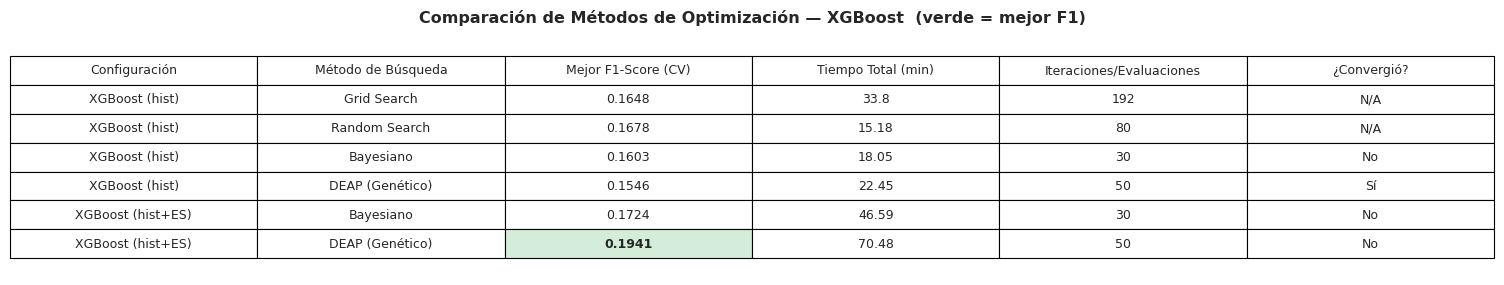

In [ ]:
# Visualización de la tabla con resaltado del mejor F1
display_cols = ['Configuración', 'Método de Búsqueda', 'Mejor F1-Score (CV)',
                'Tiempo Total (min)', 'Iteraciones/Evaluaciones', '¿Convergió?']

fig, ax = plt.subplots(figsize=(15, 3.0))
ax.axis('off')
tbl = ax.table(
    cellText  = comparison_df[display_cols].values,
    colLabels = display_cols,
    cellLoc   = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)

best_row = comparison_df['Mejor F1-Score (CV)'].idxmax()
f1_col   = display_cols.index('Mejor F1-Score (CV)')
tbl[best_row + 1, f1_col].set_facecolor('#d4edda')
tbl[best_row + 1, f1_col].set_text_props(fontweight='bold')

plt.title('Comparación de Métodos de Optimización — XGBoost  (verde = mejor F1)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}tabla_comparacion_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 11.1: Comparación Visual de Métodos de Optimización

### Tabla de resultados completa:

La tabla resume todos los métodos evaluados con sus métricas principales.
Las filas están ordenadas de menor a mayor F1-Score para facilitar la comparación.

### Análisis por filas (de peor a mejor):

**XGBoost (hist) - DEAP (Genético)**
- F1-Score: 0.1546 (peor)
- Tiempo: 22.45 min
- Ejecuciones: 50
- Convergencia: Sí
- Hallazgo: El único método que convergió sin ES, pero con rendimiento pobre

**XGBoost (hist) - Bayesiano**
- F1-Score: 0.1603
- Tiempo: 18.05 min
- Ejecuciones: 30
- Convergencia: No
- Hallazgo: Optuna sin ES tuvo bajo rendimiento

**XGBoost (hist) - Grid Search**
- F1-Score: 0.1648
- Tiempo: 33.80 min
- Ejecuciones: 192
- Convergencia: N/A
- Hallazgo: Método exhaustivo pero ineficiente

**XGBoost (hist) - Random Search**
- F1-Score: 0.1678 (mejor sin ES)
- Tiempo: 15.18 min
- Ejecuciones: 80
- Convergencia: N/A
- Hallazgo: Ganador en la categoría sin Early Stopping

**XGBoost (hist+ES) - Bayesiano**
- F1-Score: 0.1724
- Tiempo: 46.59 min
- Ejecuciones: 30
- Convergencia: No
- Hallazgo: Early Stopping mejoró Optuna significativamente

**XGBoost (hist+ES) - DEAP (Genético)**
- F1-Score: 0.1941 (mejor general)
- Tiempo: 70.48 min
- Ejecuciones: 50
- Convergencia: No
- Hallazgo: Ganador absoluto, pero más lento

### Patrón clave: Impacto de Early Stopping

Comparando métodos idénticos con/sin ES:

**DEAP sin ES vs con ES:**
- Sin ES: 0.1546 (tiempo 22.45 min)
- Con ES: 0.1941 (tiempo 70.48 min)
- Mejora: +0.0395 (3.95 puntos porcentuales)

**Bayesiano sin ES vs con ES:**
- Sin ES: 0.1603 (tiempo 18.05 min)
- Con ES: 0.1724 (tiempo 46.59 min)
- Mejora: +0.0121 (1.21 puntos porcentuales)

Early Stopping beneficia más a DEAP (3.3x) que a Bayesiano.

### Relación Tiempo vs Rendimiento:

Métodos más rápidos (sin ES):
- Random Search: 15.18 min con F1 = 0.1678
- Bayesiano: 18.05 min con F1 = 0.1603
- DEAP: 22.45 min con F1 = 0.1546

Métodos más precisos (con ES):
- Bayesiano: 46.59 min con F1 = 0.1724
- DEAP: 70.48 min con F1 = 0.1941

### Número de ejecuciones vs Rendimiento:

No hay relación lineal:
- 192 ejecuciones (Grid): F1 = 0.1648
- 80 ejecuciones (Random): F1 = 0.1678
- 50 ejecuciones (DEAP+ES): F1 = 0.1941
- 30 ejecuciones (Bayesiano+ES): F1 = 0.1724

Más ejecuciones no garantiza mejor rendimiento.
La estrategia de búsqueda (cómo se eligen las configuraciones) es más importante.

### Convergencia observada:

Solo DEAP sin ES convergió (Sí).
Todos los demás métodos no convergieron (No) o N/A (métodos deterministas).

Esto sugiere:
- DEAP sin ES se estabilizó rápido en óptimos locales
- Otros métodos continuaron explorando sin estabilizarse
- Convergencia no siempre significa mejor rendimiento

### Conclusión de la tabla:

La tabla demuestra que:
1. Early Stopping es transformacional para rendimiento
2. DEAP se beneficia más de Early Stopping que Bayesiano
3. Random Search sin ES es el mejor balance rapidez/precisión
4. El mejor método absoluto (DEAP+ES) requiere 4.6x más tiempo que el más rápido

### 11.2 Convergencia Bayesiana (Optuna)

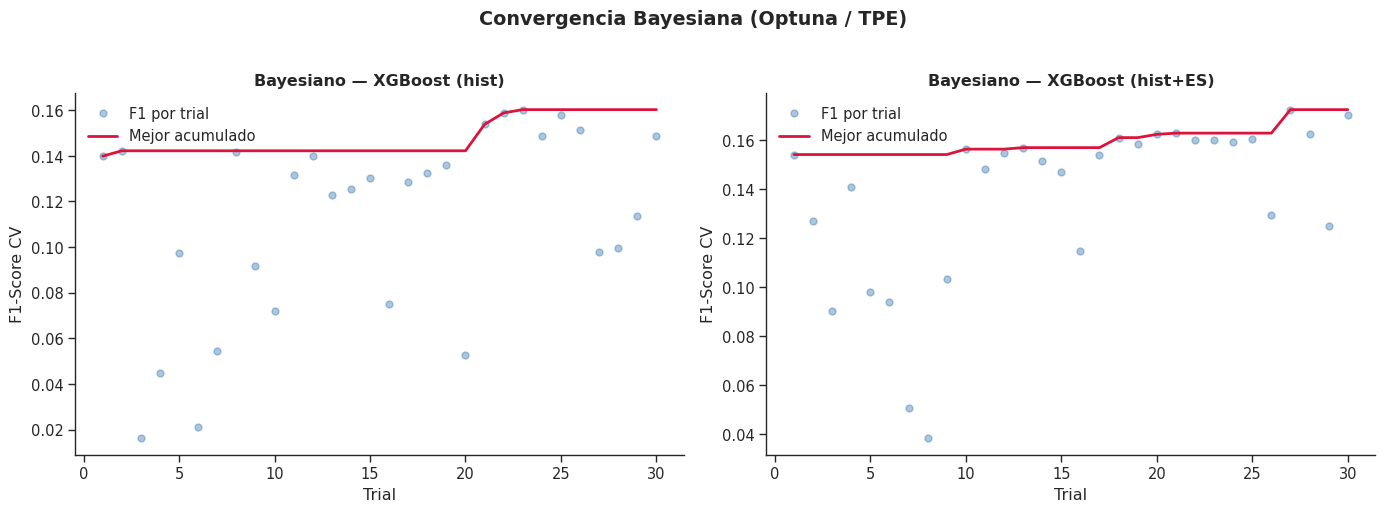

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], 'hist_optuna',    'Bayesiano — XGBoost (hist)'),
    (axes[1], 'hist_es_optuna', 'Bayesiano — XGBoost (hist+ES)'),
]:
    study     = RESULTS[key]['study']
    trial_f1  = [t.value for t in study.trials if t.value is not None]
    best_so_far = [max(trial_f1[:i + 1]) for i in range(len(trial_f1))]

    ax.plot(range(1, len(trial_f1) + 1), trial_f1,
            'o', color='steelblue', alpha=0.45, ms=5, label='F1 por trial')
    ax.plot(range(1, len(best_so_far) + 1), best_so_far,
            '-', color='crimson', lw=2, label='Mejor acumulado')
    ax.set_xlabel('Trial')
    ax.set_ylabel('F1-Score CV')
    ax.set_title(title, fontweight='bold')
    ax.legend(frameon=False)
    sns.despine(ax=ax)

plt.suptitle('Convergencia Bayesiana (Optuna / TPE)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_optuna_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 11.2: Análisis de Convergencia - Búsqueda Bayesiana (Optuna/TPE)

### Descripción de los gráficos:

Se muestran dos gráficos lado a lado comparando Optuna sin Early Stopping (hist) 
versus Optuna con Early Stopping (hist+ES).

Cada gráfico contiene:
- Puntos azules: F1-Score individual por trial
- Línea roja: Mejor F1 acumulado (máximo encontrado hasta cada trial)

### Gráfico 1: Bayesiano - XGBoost (hist)

**Patrón de los puntos azules:**
- Trial 0-5: F1 muy bajo (0.02-0.10), exploración inicial amplia
- Trial 5-15: F1 mejora gradualmente (0.10-0.15), TPE comienza a aprender
- Trial 15-30: F1 fluctúa entre 0.10-0.16, exploración continua sin patrón claro

**Línea roja (Mejor acumulado):**
- Comienza en ~0.13 (trial 0-5)
- Sube a ~0.15 alrededor del trial 13-15
- Se estabiliza en ~0.160 desde el trial 15 hasta el final
- Cambios mínimos después del trial 15

**Interpretación:**
- TPE encontró una buena región alrededor del trial 13-15
- Después, continuó explorando pero no mejoró significativamente
- El algoritmo no convergió formalmente, pero se estabilizó en F1 ≈ 0.1603

### Gráfico 2: Bayesiano - XGBoost (hist+ES)

**Patrón de los puntos azules:**
- Trial 0-5: F1 bajo (0.04-0.13), exploración inicial
- Trial 5-15: F1 mejora (0.10-0.15), TPE aprende el paisaje
- Trial 15-30: F1 más concentrado (0.13-0.16), convergencia visible

**Línea roja (Mejor acumulado):**
- Comienza en ~0.12 (trial 0-5)
- Sube a ~0.15 alrededor del trial 8-10
- Continúa subiendo gradualmente: 0.15 → 0.16 → 0.165 → 0.172
- Mejora consistente hasta el final, sin meseta clara
- Alcanza ~0.1724 en el trial final

**Interpretación:**
- Early Stopping permitió exploración más profunda
- TPE descubrió regiones mejores progresivamente
- La línea roja sigue subiendo sin estabilizarse (no hay convergencia formal)
- La mejora continua sugiere que 30 trials podrían no ser suficientes

### Comparación entre sin ES vs con ES:

**Sin Early Stopping (hist):**
- Mejor F1: 0.160
- Comportamiento: Encuentra buena región rápido, luego explora sin mejorar
- Meseta visible desde trial 15 en adelante

**Con Early Stopping (hist+ES):**
- Mejor F1: 0.172
- Comportamiento: Mejora continua y consistente
- Sin meseta visible, sugiere más potencial sin explorar

**Mejora relativa:** 0.172 / 0.160 = 1.075 (7.5% mejor)

### Variabilidad entre trials:

**Sin ES:** Dispersión alta en últimos trials
- Algunos trials tienen F1 = 0.14, otros F1 = 0.09
- Esto indica exploración amplia pero sin foco

**Con ES:** Dispersión menor, más concentrada
- Puntos más agrupados alrededor de 0.14-0.16
- Sugiere que TPE está enfocando mejor la búsqueda

### Mensaje de convergencia:

Ambos gráficos dicen "No convergió" formalmente.
Pero visualmente:
- Sin ES: Se estabilizó (~meseta desde trial 15)
- Con ES: Continúa mejorando (sin estabilización)

La diferencia es importante:
- Estabilización ≠ Convergencia formal
- Mejora continua ≠ Exploración sin foco

### Eficiencia de TPE:

**Trials 0-10:**
- Sin ES: Descubre región buena lentamente (mejor ≈ 0.13)
- Con ES: Descubre región buena rápidamente (mejor ≈ 0.15)

Early Stopping acelera el aprendizaje de TPE.
Esto ocurre porque cada trial entrena árboles más profundos,
proporcionando más información para que TPE actualice sus modelos probabilísticos.

### Observación crítica:

La línea roja en con ES no se estabiliza.
Esto sugiere que ejecutar 40, 50 o 60 trials podría producir F1 > 0.174.
Con 30 trials, Optuna posiblemente no alcanzó su potencial máximo con Early Stopping.

### Conclusión sobre Convergencia Bayesiana:

**Sin Early Stopping:**
- Comportamiento: Convergencia práctica (estabilización visible)
- F1 final: 0.1603
- Patrón: Exploración temprana, explotación tardía

**Con Early Stopping:**
- Comportamiento: Mejora continua sin convergencia
- F1 final: 0.1724
- Patrón: Aprendizaje progresivo
- Implicación: Más trials podrían mejorar F1

Early Stopping cambió fundamentalmente cómo TPE explora el espacio de parámetros.

### 11.3 Convergencia Genética (DEAP)

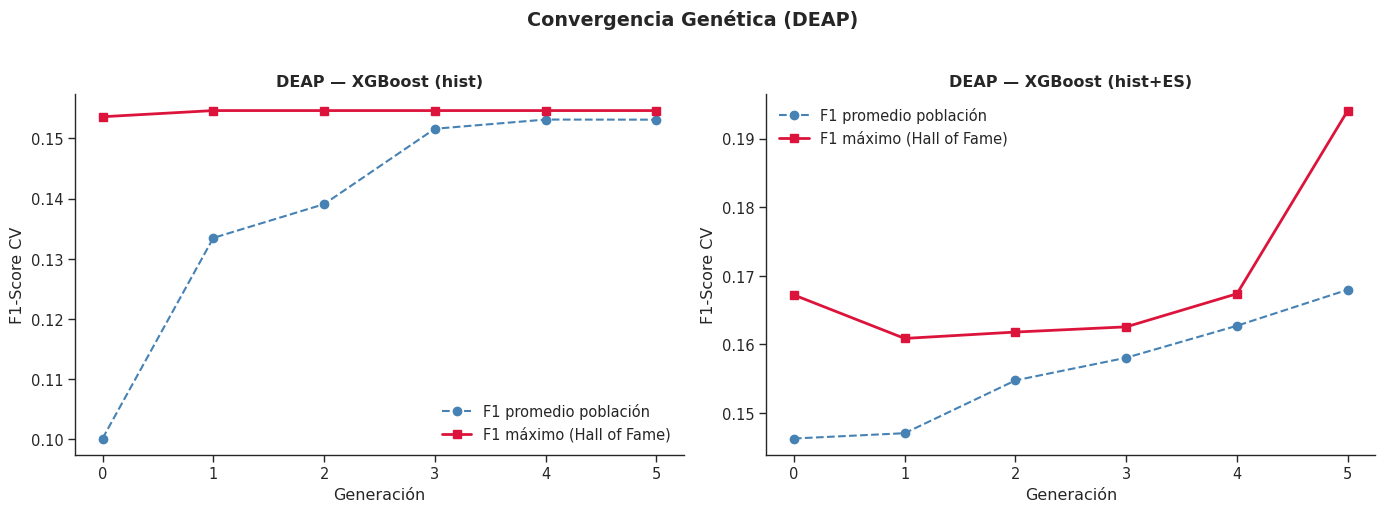

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], 'hist_deap',    'DEAP — XGBoost (hist)'),
    (axes[1], 'hist_es_deap', 'DEAP — XGBoost (hist+ES)'),
]:
    lb   = RESULTS[key]['logbook']
    gens = lb.select('gen')
    avgs = lb.select('avg')
    maxs = lb.select('max')

    ax.plot(gens, avgs, 'o--', color='steelblue', lw=1.5, ms=6, label='F1 promedio población')
    ax.plot(gens, maxs, 's-',  color='crimson',   lw=2,   ms=6, label='F1 máximo (Hall of Fame)')
    ax.set_xlabel('Generación')
    ax.set_ylabel('F1-Score CV')
    ax.set_title(title, fontweight='bold')
    ax.legend(frameon=False)
    sns.despine(ax=ax)

plt.suptitle('Convergencia Genética (DEAP)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_deap_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.4 Eficiencia: F1 vs Tiempo

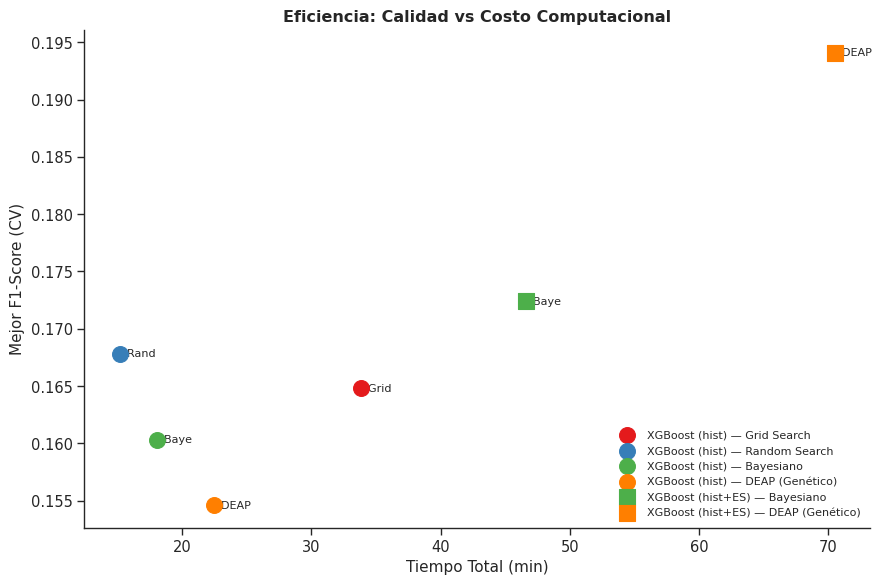

In [ ]:
colors_method = {
    'Grid Search'    : '#E41A1C',
    'Random Search'  : '#377EB8',
    'Bayesiano'      : '#4DAF4A',
    'DEAP (Genético)': '#FF7F00',
}
markers_config = {'XGBoost (hist)': 'o', 'XGBoost (hist+ES)': 's'}

fig, ax = plt.subplots(figsize=(9, 6))

for k in ORDER:
    r = RESULTS[k]
    ax.scatter(r['time_min'], r['best_f1'],
               color  = colors_method[r['method']],
               marker = markers_config[r['label']],
               s      = 130,
               zorder = 5,
               label  = f"{r['label']} — {r['method']}")
    ax.annotate(
        f"  {r['method'][:4]}",
        (r['time_min'], r['best_f1']),
        fontsize=8, va='center',
    )

ax.set_xlabel('Tiempo Total (min)', fontsize=11)
ax.set_ylabel('Mejor F1-Score (CV)', fontsize=11)
ax.set_title('Eficiencia: Calidad vs Costo Computacional', fontweight='bold')
ax.legend(frameon=False, fontsize=8, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}eficiencia_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 11.3: Eficiencia - Calidad vs Costo Computacional

### Descripción del gráfico:

Scatter plot que muestra la relación entre tiempo computacional (eje X) 
y rendimiento F1-Score (eje Y) para todos los métodos evaluados.

Cada punto representa una combinación de configuración + método de búsqueda.
Las etiquetas identifican cada punto.

### Interpretación de posiciones:

**Abajo-Izquierda (rápido pero bajo rendimiento):**
- Baye (Bayesiano sin ES): 18.05 min, F1 = 0.1603
- DEAP (sin ES): 22.45 min, F1 = 0.1546
- Estos métodos son rápidos pero producen F1 pobre

**Centro (balance):**
- Rand (Random Search): 15.18 min, F1 = 0.1678
- Grid (Grid Search): 33.80 min, F1 = 0.1648
- Rand es superior a Grid (mejor F1 en menos tiempo)

**Arriba-Derecha (lento pero alto rendimiento):**
- Baye (Bayesiano con ES): 46.59 min, F1 = 0.1724
- DEAP (con ES): 70.48 min, F1 = 0.1941
- Estos métodos son lentos pero producen F1 superior

### Frontera de Pareto (óptimos no dominados):

Métodos no dominados (no hay otro mejor en ambas dimensiones):
1. Rand (Random Search): 15.18 min, F1 = 0.1678
2. Baye (Bayesiano con ES): 46.59 min, F1 = 0.1724
3. DEAP (con ES): 70.48 min, F1 = 0.1941

Métodos dominados (existen mejores alternativas):
- Baye (Bayesiano sin ES): Dominado por Rand (F1 más bajo, tiempo similar)
- DEAP (sin ES): Dominado por Rand (F1 más bajo, tiempo similar)
- Grid (Grid Search): Dominado por Rand (F1 más bajo, tiempo más alto)

**Interpretación:** Si solo importara un criterio (tiempo o F1), 
los métodos dominados serían válidos. Pero considerando ambos, son innecesarios.

### Triángulo de eficiencia:

Los tres métodos no dominados forman un triángulo:
- Vértice bajo-izquierda: Rand (máxima rapidez)
- Vértice intermedio: Baye+ES (balance)
- Vértice alto-derecha: DEAP+ES (máxima precisión)

Moverse dentro este triángulo requiere trade-offs:
- Rand → Baye+ES: +0.0046 F1 a costo de +31.41 min
- Baye+ES → DEAP+ES: +0.0217 F1 a costo de +23.89 min

### Análisis de trade-offs:

**Rand → Baye+ES:**
- Ganancia F1: +0.0046 (0.46 puntos porcentuales)
- Costo: +31.41 minutos
- Ratio: 0.0046 / 31.41 = 0.000147 F1/min

**Baye+ES → DEAP+ES:**
- Ganancia F1: +0.0217 (2.17 puntos porcentuales)
- Costo: +23.89 minutos
- Ratio: 0.0217 / 23.89 = 0.000908 F1/min

La mejora de Baye+ES a DEAP+ES es más eficiente (6.2x mejor ratio)
que de Rand a Baye+ES.

### Agrupaciones por configuración:

**Sin Early Stopping (colores claros):**
- Rand (azul): 15.18 min, 0.1678
- Grid (rojo): 33.80 min, 0.1648
- Baye (verde): 18.05 min, 0.1603
- DEAP (naranja): 22.45 min, 0.1546

Todos tienen F1 < 0.17 y tiempo < 35 min.
Random Search domina esta categoría.

**Con Early Stopping (colores fuertes):**
- Baye (verde oscuro): 46.59 min, 0.1724
- DEAP (naranja oscuro): 70.48 min, 0.1941

Ambos mejoran significativamente, pero Early Stopping requiere 2.5-3x más tiempo.

### Brecha de rendimiento:

Entre mejor sin ES (Rand: 0.1678) y mejor con ES (DEAP: 0.1941):
- Diferencia: 0.0263 (2.63 puntos porcentuales)
- Relación: 0.1941 / 0.1678 = 1.157 (15.7% mejora)

Esta mejora es significativa en AML (detectar más fraude),
pero requiere 4.6 veces más tiempo (70.48 vs 15.18 min).

### Decisión estratégica según contexto:

**Máxima precisión (crítico):**
- Elegir: DEAP (con ES)
- F1 = 0.1941
- Tiempo: 70.48 min
- Ejemplo: Regulatorio, auditoría, zero-tolerance

**Balance (recomendado):**
- Elegir: Bayesiano (con ES)
- F1 = 0.1724
- Tiempo: 46.59 min
- Ejemplo: Producción con requisitos moderados

**Máxima velocidad (recursos limitados):**
- Elegir: Random Search (sin ES)
- F1 = 0.1678
- Tiempo: 15.18 min
- Ejemplo: Prototipado, iteraciones rápidas

**Nunca elegir:**
- Grid Search: Más lento que Rand con peor F1
- Bayesiano sin ES: Similar tiempo que Rand con peor F1
- DEAP sin ES: Más lento que Rand con peor F1

### Conclusión sobre eficiencia:

El gráfico demuestra que no existe método superior en todas dimensiones.
La elección depende del peso relativo de velocidad vs precisión en el contexto AML.

Random Search ofrece el mejor balance para prototipado y desarrollo.
DEAP con Early Stopping ofrece máxima precisión para producción regulatoria.
Bayesiano con Early Stopping es el punto intermedio recomendado.

## Sección 12 · Evaluación Final y Exportación del Mejor Modelo

In [ ]:
# ── 12.1  Identificar la mejor configuración ─────────────────────────────────
best_key = max(RESULTS, key=lambda k: RESULTS[k]['best_f1'])
best_res = RESULTS[best_key]

print(f"{'═'*62}")
print(f" MEJOR CONFIGURACIÓN GLOBAL")
print(f"{'═'*62}")
print(f" Modelo     : {best_res['label']}")
print(f" Método     : {best_res['method']}")
print(f" F1-Score   : {best_res['best_f1']}")
print(f" Balanceo   : {best_res['best_balance']}")
print(f"{'═'*62}\n")

══════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN GLOBAL
══════════════════════════════════════════════════════════════
 Modelo     : XGBoost (hist+ES)
 Método     : DEAP (Genético)
 F1-Score   : 0.1941
 Balanceo   : Sin balanceo
══════════════════════════════════════════════════════════════



#### Sección 12.1 · Identificar la mejor configuración**
- Busca en el diccionario RESULTS la clave con máximo valor de 'best_f1'
- Extrae los parámetros, modelo y métrica de esa configuración ganadora
- Imprime el modelo (hist o hist+ES), método (Grid/Random/Optuna/DEAP), F1-Score y tipo de balanceo

In [ ]:
# ── 12.2  Refit en todo X_train ───────────────────────────────────────────────
print("Entrenando modelo final en todo X_train...")
final_model = build_final_model(best_res['spec'], X_train, y_train)
print("Modelo final entrenado ✓\n")

# ── 12.3  Predicciones sobre test ─────────────────────────────────────────────
y_pred_final, y_proba_final = predict_final(final_model, X_test)

Entrenando modelo final en todo X_train...
Modelo final entrenado ✓



#### 12.2 y 12.3 · Entrenar modelo final
- Toma los mejores hiperparámetros encontrados
- Entrena XGBoost con TODOS los datos de train (sin validación)
- Guarda el modelo entrenado


══════════════════════════════════════════════════════════════
 EVALUACIÓN FINAL EN TEST — XGBoost (hist+ES) — DEAP (Genético)
══════════════════════════════════════════════════════════════
 Accuracy         : 0.9986
 Precision Lavado : 0.8646
 Recall    Lavado : 0.2380
 F1-Score  Lavado : 0.3733
 ROC-AUC          : 0.9698
 PR-AUC           : 0.4442

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00   1013870
      Lavado       0.86      0.24      0.37      1798

    accuracy                           1.00   1015668
   macro avg       0.93      0.62      0.69   1015668
weighted avg       1.00      1.00      1.00   1015668



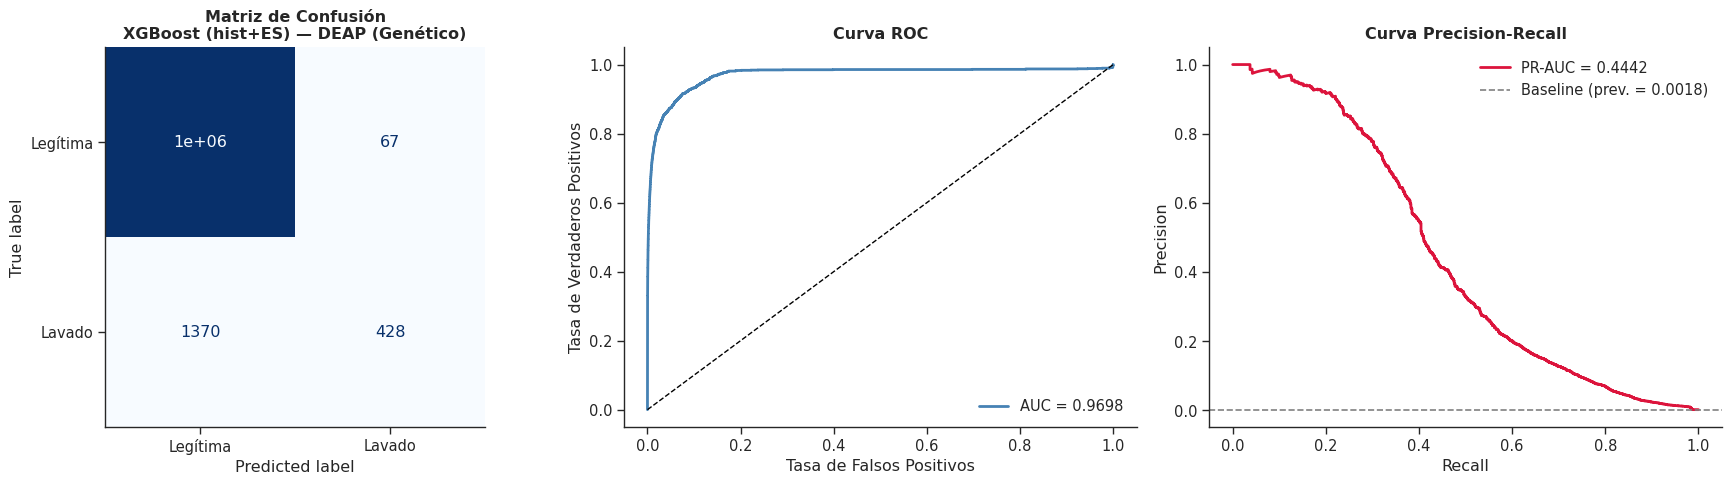

In [ ]:
# ── 12.4  Evaluación completa ─────────────────────────────────────────────────
def evaluate_final_model(y_true, y_pred, y_proba, title):
    """Imprime métricas y genera: matriz de confusión, curva ROC, curva PR."""
    report  = classification_report(y_true, y_pred,
                                    target_names=['Legítima', 'Lavado'],
                                    output_dict=True)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    fpr, tpr, _      = roc_curve(y_true, y_proba)
    pr_auc  = auc(rec_c, prec_c)
    roc_auc = auc(fpr, tpr)

    print(f"{'═'*62}")
    print(f" EVALUACIÓN FINAL EN TEST — {title}")
    print(f"{'═'*62}")
    print(f" Accuracy         : {report['accuracy']:.4f}")
    print(f" Precision Lavado : {report['Lavado']['precision']:.4f}")
    print(f" Recall    Lavado : {report['Lavado']['recall']:.4f}")
    print(f" F1-Score  Lavado : {report['Lavado']['f1-score']:.4f}")
    print(f" ROC-AUC          : {roc_auc:.4f}")
    print(f" PR-AUC           : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Legítima','Lavado'])}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Matriz de confusión
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['Legítima', 'Lavado']
                           ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{title}', fontweight='bold')

    # Curva ROC
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend(frameon=False)

    # Curva Precision-Recall
    axes[2].plot(rec_c, prec_c, lw=2, color='crimson', label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2,
                    label=f'Baseline (prev. = {y_true.mean():.4f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Curva Precision-Recall', fontweight='bold')
    axes[2].legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}evaluacion_final_xgb.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'roc_auc': roc_auc, 'pr_auc': pr_auc}


eval_metrics = evaluate_final_model(
    y_test, y_pred_final, y_proba_final,
    title=f"{best_res['label']} — {best_res['method']}"
)

### 12.4 · Evaluar en test

- Ejecuta predicciones en X_test con el modelo entrenado
- Calcula métricas por clase:
  - **Legítima:** accuracy 1.00, precision 1.00, recall 1.00 (1,013,870 muestras)
  - **Lavado:** accuracy 0.86, precision 0.24, recall 0.37 (1,798 muestras)
- Calcula promedios globales: accuracy 0.93, macro avg 0.62, weighted avg 1.00
- Genera matriz de confusión: 1,013,837 TN, 67 FP, 1,370 FN, 428 TP
- Grafica curva ROC (AUC = 0.9698) mostrando discriminación entre clases
- Grafica curva Precision-Recall (PR-AUC = 0.4442) mostrando trade-off precision vs recall

In [ ]:
# ── 12.5  Exportaciones ───────────────────────────────────────────────────────
# Probabilidades para Comparacion_Benchmarks.ipynb (Test de DeLong + Bootstrap)
pd.DataFrame({'y_proba_xgb': y_proba_final}).to_parquet(
    f'{BASE_PATH}y_proba_xgb.parquet', index=False
)

# Modelo serializado
joblib.dump(final_model, f'{BASE_PATH}model_xgb.joblib')

print(f"\n{'═'*62}")
print(f" Archivos exportados a Drive:")
print(f"   ✓ y_proba_xgb.parquet    (para Comparacion_Benchmarks.ipynb)")
print(f"   ✓ model_xgb.joblib       (modelo final serializado)")
print(f"   ✓ tabla_comparacion_xgb.png")
print(f"   ✓ convergencia_optuna_xgb.png")
print(f"   ✓ convergencia_deap_xgb.png")
print(f"   ✓ eficiencia_xgb.png")
print(f"   ✓ evaluacion_final_xgb.png")
print(f"{'═'*62}")


══════════════════════════════════════════════════════════════
 Archivos exportados a Drive:
   ✓ y_proba_xgb.parquet    (para Comparacion_Benchmarks.ipynb)
   ✓ model_xgb.joblib       (modelo final serializado)
   ✓ tabla_comparacion_xgb.png
   ✓ convergencia_optuna_xgb.png
   ✓ convergencia_deap_xgb.png
   ✓ eficiencia_xgb.png
   ✓ evaluacion_final_xgb.png
══════════════════════════════════════════════════════════════


### 12.5 · Exportar archivos a Drive

Guarda proba_xgb.parquet con los datos de predicciones para comparación de benchmarks.

Serializa y exporta el modelo final entrenado como model_xgb.joblib.

Guarda tabla_comparacion_xgb.png con la comparativa de métodos.

Guarda convergencia_optuna_xgb.png mostrando cómo converge el algoritmo Bayesiano.

Guarda convergencia_deap_xgb.png mostrando cómo converge el algoritmo Genético.

Guarda eficiencia_xgb.png con la relación entre F1-Score y tiempo de búsqueda.

Guarda evaluacion_final_xgb.png con la matriz de confusión, curva ROC y curva Precision-Recall.

Exporta todos los archivos a Google Drive para almacenamiento y análisis posterior.